# Decoys vs supported cryptics: exploring the final feature table

Loads `results/decoy_intron_features_final.tsv` (written by Part 4 of
`scripts/compile_decoy_intron_data.Rmd`) and compares the two site classes.
Every feature was computed the same way for both classes; `site_class` is the only
thing that separates them. `HNRNPH1_179620582` is marked with a black star on every plot.

Sections:

- **A.** Retention propensity: proportion of sites with PSI > 10 in at least *k* tissues, with a fitted logistic curve per class
- **B.** Tissue count against local SpliceAI score, MaxEnt and intron GC, with negative-binomial regression lines
- **C.** GC content against tissue count, as percent-of-class density
- **D.** Statistics: effect sizes per feature, a logistic model of class, and a negative-binomial model of tissue count
- **E.** Further exploration plots

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd() if (Path.cwd() / "results").exists() else Path.cwd().parent
FIG = ROOT / "figures" / "notebook"
FIG.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "psi_count_ge10", "psi_count_ge10_brain", "intron_length", "intron_gc", "site_gc_49nt",
    "SpliceAI_score", "decoy_distance_from_canonical_5ss",
    "MaxEnt_decoy", "MaxEnt_canonical", "phastCons100_mean", "phastCons470_mean",
]
LABEL = {
    "psi_count_ge10": "Tissues with PSI > 10",
    "psi_count_ge10_brain": "Brain tissues with PSI > 10",
    "intron_length": "Intron length (nt)",
    "intron_gc": "Intron GC fraction",
    "site_gc_49nt": "Site GC fraction (49 nt)",
    "SpliceAI_score": "Local SpliceAI donor score",
    "decoy_distance_from_canonical_5ss": "Distance from canonical 5'SS (nt)",
    "MaxEnt_decoy": "MaxEnt (site)",
    "MaxEnt_canonical": "MaxEnt (canonical 5'SS)",
    "phastCons100_mean": "phastCons 100-way (intron mean)",
    "phastCons470_mean": "phastCons 470-way (intron mean)",
}
keep = set(FEATURES) | {"decoyID", "GENE", "site_class", "n_categories", "brain_retained", "chr", "start", "strand"}
df = pd.read_csv(ROOT / "results" / "decoy_intron_features_final.tsv", sep="\t", usecols=lambda c: c in keep)

CLASSES = ["decoy", "cryptic_supported"]
CLASS_LABEL = {"decoy": "Decoys", "cryptic_supported": "Supported cryptics"}
COLOR = {"decoy": "#B2182B", "cryptic_supported": "#2166AC"}
df["site_class"] = pd.Categorical(df["site_class"], categories=CLASSES)
df["class_label"] = df["site_class"].map(CLASS_LABEL)
df["log10_intron_length"] = np.log10(df["intron_length"])
df["maxent_delta"] = df["MaxEnt_decoy"] - df["MaxEnt_canonical"]

HN = df.loc[df["decoyID"] == "HNRNPH1_179620582"]
assert len(HN) == 1 and HN["site_class"].iloc[0] == "decoy", "HNRNPH1 decoy missing from the table"
HN = HN.iloc[0]

def mark_hnrnph1(ax, x, y, label=True, dy=6):
    # Black star at (x, y); the label flips left when x is in the right quarter of the axis.
    ax.scatter([x], [y], marker="*", s=260, facecolor="black", edgecolor="white", linewidth=0.8, zorder=10)
    if label:
        lo, hi = ax.get_xlim()
        if ax.get_xscale() == "log":
            right = np.log10(x) > np.log10(lo) + 0.75 * (np.log10(hi) - np.log10(lo))
        else:
            right = x > lo + 0.75 * (hi - lo)
        ax.annotate("HNRNPH1", (x, y), xytext=(-8 if right else 8, dy), textcoords="offset points",
                    ha="right" if right else "left", fontsize=9, fontweight="bold", zorder=11)

def save(fig, name):
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

sns.set_theme(style="whitegrid", context="notebook")
n_class = df["site_class"].value_counts()
print(n_class.to_string())
print()
print("HNRNPH1:", HN[FEATURES].to_dict())

site_class
cryptic_supported    17721
decoy                 6497

HNRNPH1: {'psi_count_ge10': 118, 'psi_count_ge10_brain': 21, 'intron_length': 1484, 'intron_gc': 0.320081, 'site_gc_49nt': 0.428571, 'SpliceAI_score': 0.256819, 'decoy_distance_from_canonical_5ss': 308, 'MaxEnt_decoy': 10.57, 'MaxEnt_canonical': 9.8, 'phastCons100_mean': 0.452456, 'phastCons470_mean': 0.750053}


## A. Retention propensity curve

For each class, the proportion of sites whose intron has PSI > 10 in at least *k* tissues,
plotted against *k*. Proportions cancel the class-size difference (17,721 vs 6,497).
The fitted curve is a logistic regression of the per-site indicator `psi_count_ge10 >= k`
on log(1 + *k*), fitted per class. The two classes are compared on the underlying counts
(Kolmogorov-Smirnov, and Cliff's delta in section D), not on the stacked curve rows, which
are not independent observations.

KS test on tissue counts, decoys vs cryptics: D = 0.065, p = 8.2e-18
Decoys               fitted P(retained >= k) drops below 0.5 at k = 21;  observed median = 20
Supported cryptics   fitted P(retained >= k) drops below 0.5 at k = 19;  observed median = 18


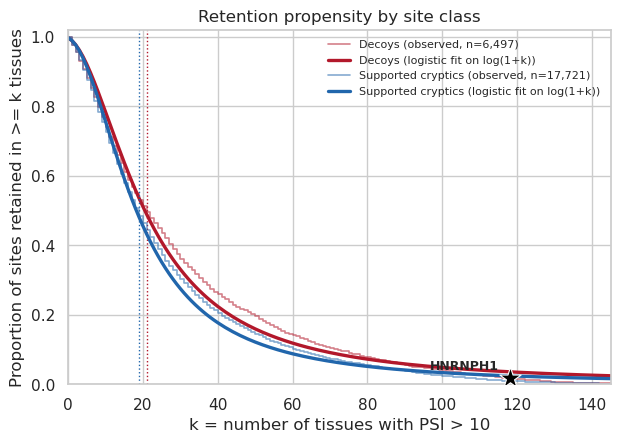

In [2]:
K = np.arange(0, 146)
n_tissues = int(df["psi_count_ge10"].max())

# Long table: one row per (site, k) with the retained indicator. 24k x 146 = 3.5M rows.
long = pd.DataFrame({
    "k": np.tile(K, len(df)),
    "retained": (df["psi_count_ge10"].to_numpy()[:, None] >= K[None, :]).ravel().astype(int),
    "site_class": np.repeat(df["site_class"].astype(str).to_numpy(), len(K)),
})
long["is_decoy"] = (long["site_class"] == "decoy").astype(int)

long["log1p_k"] = np.log1p(long["k"])
emp = long.groupby(["site_class", "k"])["retained"].mean().unstack(0)

fits = {}
for cls in CLASSES:
    sub = long[long["site_class"] == cls]
    fits[cls] = smf.glm("retained ~ log1p_k", data=sub, family=sm.families.Binomial()).fit()

ks = stats.ks_2samp(df.loc[df.site_class == "decoy", "psi_count_ge10"], df.loc[df.site_class == "cryptic_supported", "psi_count_ge10"])
print(f"KS test on tissue counts, decoys vs cryptics: D = {ks.statistic:.3f}, p = {ks.pvalue:.2g}")

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.set_xlim(0, n_tissues); ax.set_ylim(0, 1.02)
for cls in CLASSES:
    ax.step(K, emp[cls], where="post", color=COLOR[cls], lw=1.2, alpha=0.55, label=f"{CLASS_LABEL[cls]} (observed, n={n_class[cls]:,})")
    pred = fits[cls].predict(pd.DataFrame({"log1p_k": np.log1p(K)}))
    ax.plot(K, pred, color=COLOR[cls], lw=2.4, label=f"{CLASS_LABEL[cls]} (logistic fit on log(1+k))")
    k50 = K[np.argmax(pred < 0.5)]
    ax.axvline(k50, color=COLOR[cls], ls=":", lw=1)
    print(f"{CLASS_LABEL[cls]:20s} fitted P(retained >= k) drops below 0.5 at k = {k50};  observed median = {df.loc[df.site_class == cls, 'psi_count_ge10'].median():.0f}")
k_hn = int(HN["psi_count_ge10"])
mark_hnrnph1(ax, k_hn, emp["decoy"].loc[k_hn])
ax.set_xlabel("k = number of tissues with PSI > 10")
ax.set_ylabel("Proportion of sites retained in >= k tissues")
ax.set_title("Retention propensity by site class")
ax.legend(fontsize=8, frameon=False)
save(fig, "A_retention_propensity")
plt.show()

## B. Tissue count against site features

`psi_count_ge10` is an over-dispersed count (variance ~25x the mean), so each line is a
negative-binomial GLM of the count on the feature, fitted per class, with a 95% CI on the
mean. The interaction p-value from the joint model `count ~ feature × class` says whether
the slopes differ between classes.

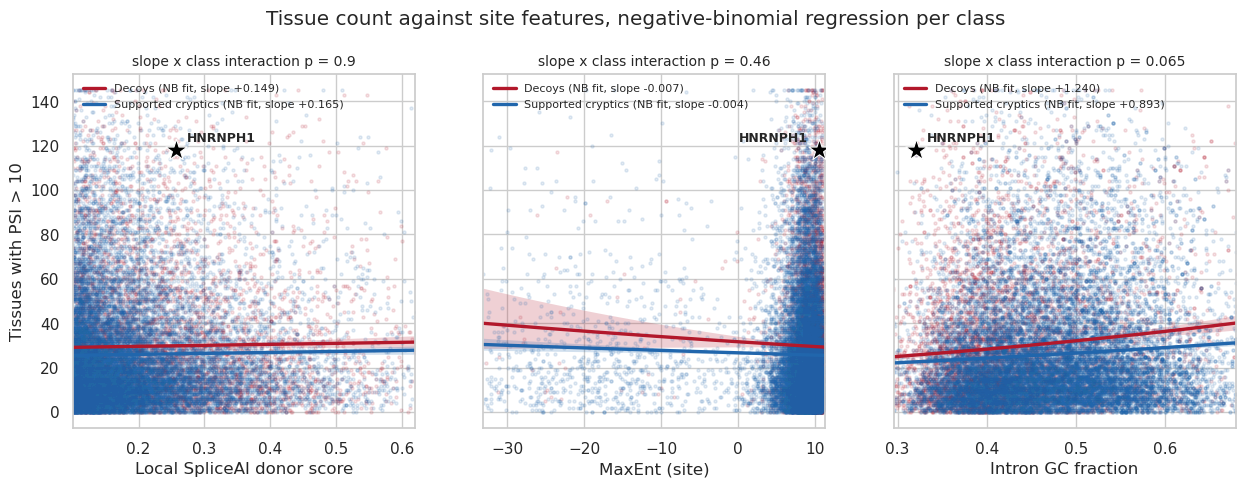

In [3]:
def nb_line(sub, x, grid):
    m = smf.glm(f"psi_count_ge10 ~ {x}", data=sub, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    pr = m.get_prediction(pd.DataFrame({x: grid})).summary_frame(alpha=0.05)
    return m, pr

panels = ["SpliceAI_score", "MaxEnt_decoy", "intron_gc"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, x in zip(axes, panels):
    lo, hi = df[x].quantile([0.005, 0.995])
    grid = np.linspace(lo, hi, 200)
    for cls in CLASSES:
        sub = df[df.site_class == cls]
        ax.scatter(sub[x], sub["psi_count_ge10"], s=5, alpha=0.12, color=COLOR[cls], rasterized=True)
        m, pr = nb_line(sub, x, grid)
        ax.plot(grid, pr["mean"], color=COLOR[cls], lw=2.4, label=f"{CLASS_LABEL[cls]} (NB fit, slope {m.params[x]:+.3f})")
        ax.fill_between(grid, pr["mean_ci_lower"], pr["mean_ci_upper"], color=COLOR[cls], alpha=0.2, lw=0)
    joint = smf.glm(f"psi_count_ge10 ~ {x} * C(site_class)", data=df, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    p_int = joint.pvalues[[c for c in joint.pvalues.index if ":" in c][0]]
    ax.set_xlim(lo, hi)
    mark_hnrnph1(ax, HN[x], HN["psi_count_ge10"])
    ax.set_xlabel(LABEL[x]); ax.set_title(f"slope x class interaction p = {p_int:.2g}", fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc="upper left")
axes[0].set_ylabel("Tissues with PSI > 10")
fig.suptitle("Tissue count against site features, negative-binomial regression per class", y=1.02)
save(fig, "B_tissue_count_vs_features")
plt.show()

## C. GC content against tissue count, percent-of-class density

Each panel is a 2D histogram in which the bins sum to 100% of that class's sites, so the
decoy and cryptic panels are directly comparable despite the different n. The colour scale
is shared across each row. The third column is the difference in percent per bin
(decoys minus cryptics): red where decoys are enriched, blue where cryptics are.

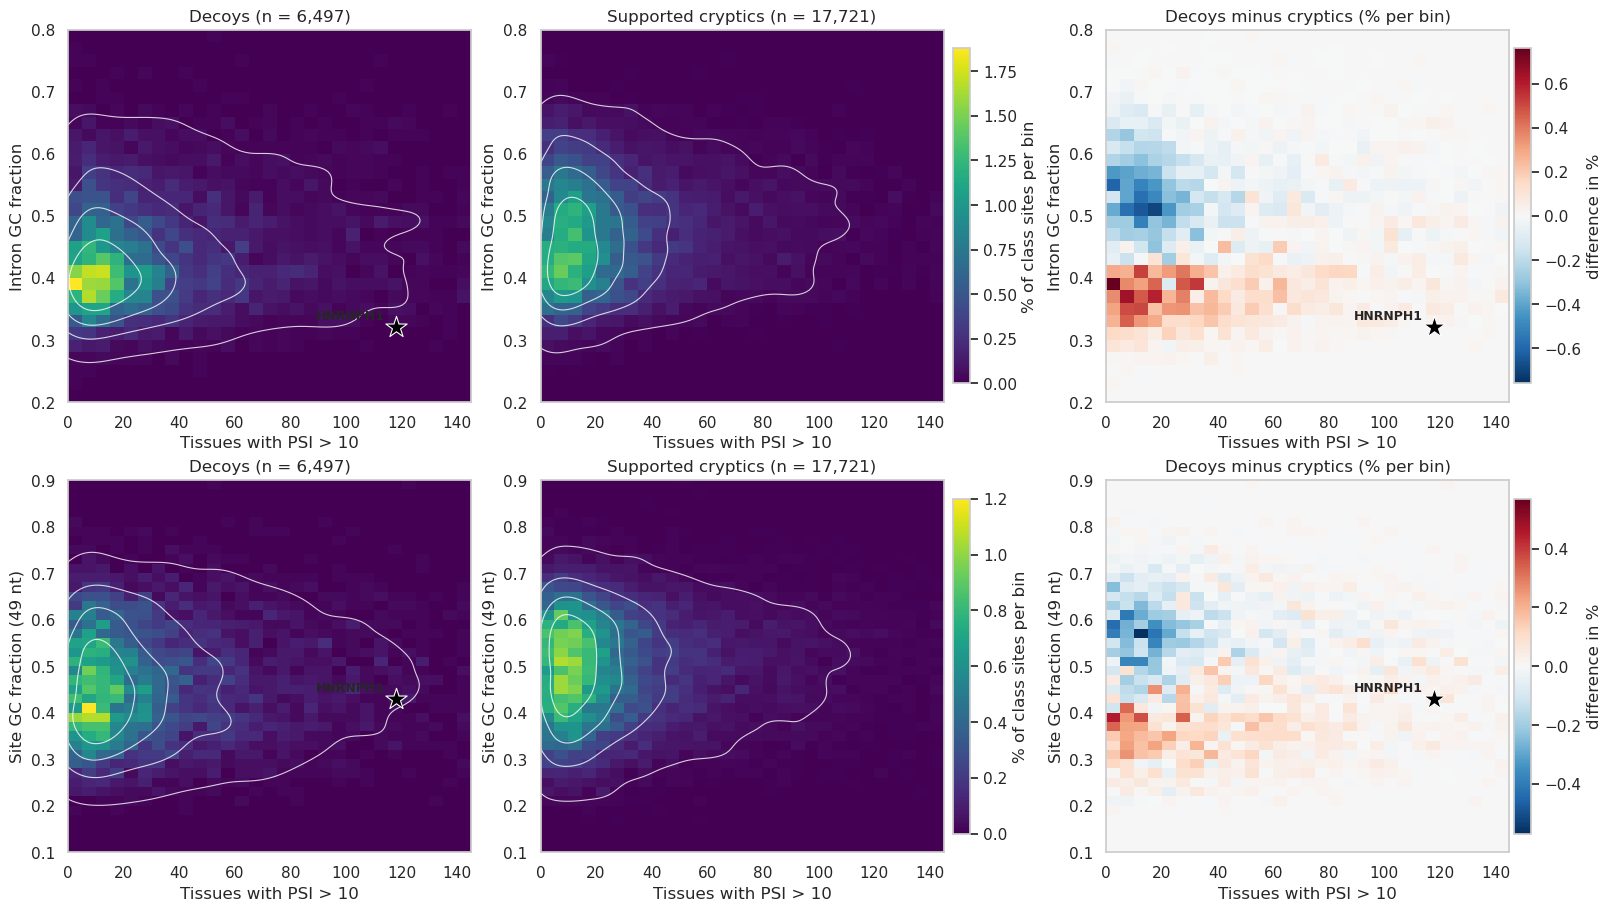

In [4]:
from matplotlib.colors import TwoSlopeNorm

x_edges = np.arange(0, 150, 5)
rows = [("intron_gc", np.arange(0.20, 0.82, 0.02)), ("site_gc_49nt", np.arange(0.10, 0.92, 0.02))]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for (y, y_edges), axrow in zip(rows, axes):
    H = {}
    for cls in CLASSES:
        sub = df[df.site_class == cls]
        h, _, _ = np.histogram2d(sub["psi_count_ge10"], sub[y], bins=[x_edges, y_edges])
        H[cls] = 100 * h / h.sum()
        assert abs(H[cls].sum() - 100) < 1e-6
    vmax = max(H[c].max() for c in CLASSES)
    for ax, cls in zip(axrow[:2], CLASSES):
        im = ax.pcolormesh(x_edges, y_edges, H[cls].T, cmap="viridis", vmin=0, vmax=vmax, shading="flat")
        sub = df[df.site_class == cls]
        sns.kdeplot(x=sub["psi_count_ge10"], y=sub[y], ax=ax, levels=5, color="white", linewidths=0.8, alpha=0.8)
        ax.set_title(f"{CLASS_LABEL[cls]} (n = {n_class[cls]:,})")
        ax.set_xlabel("Tissues with PSI > 10"); ax.set_ylabel(LABEL[y])
        ax.set_xlim(x_edges[0], x_edges[-1]); ax.set_ylim(y_edges[0], y_edges[-1])
        if cls == "decoy":
            mark_hnrnph1(ax, HN["psi_count_ge10"], HN[y])
    fig.colorbar(im, ax=axrow[:2].tolist(), label="% of class sites per bin", shrink=0.9, pad=0.01)
    diff = H["decoy"] - H["cryptic_supported"]
    lim = np.abs(diff).max()
    imd = axrow[2].pcolormesh(x_edges, y_edges, diff.T, cmap="RdBu_r", norm=TwoSlopeNorm(0, -lim, lim), shading="flat")
    axrow[2].set_title("Decoys minus cryptics (% per bin)")
    axrow[2].set_xlabel("Tissues with PSI > 10"); axrow[2].set_ylabel(LABEL[y])
    axrow[2].set_xlim(x_edges[0], x_edges[-1]); axrow[2].set_ylim(y_edges[0], y_edges[-1])
    mark_hnrnph1(axrow[2], HN["psi_count_ge10"], HN[y])
    fig.colorbar(imd, ax=axrow[2], label="difference in %", shrink=0.9, pad=0.01)
save(fig, "C_gc_vs_tissue_count_density")
plt.show()

## D. Statistics

**Why not ANOVA.** With two groups a one-way ANOVA is a t-test. The features are far from
normal (intron length and phastCons are heavily right-skewed, MaxEnt is bounded, the tissue
count is an over-dispersed count), and with n = 6,497 vs 17,721 a t-test on any of them is
"significant" at tiny effect sizes. Three things answer the actual questions:

1. **Per-feature effect size.** Mann-Whitney U with **Cliff's delta** (the probability a random
   decoy exceeds a random cryptic, minus the reverse; -1 to 1) and Benjamini-Hochberg across
   features. This is the honest version of the median table.
2. **Which features distinguish the classes jointly.** Logistic regression of class on the
   standardised features. A coefficient is the change in log-odds of being a decoy per SD of
   that feature, holding the others fixed. VIFs flag the collinear pairs.
3. **Does class predict retention after adjustment.** Negative-binomial regression of the
   tissue count on class plus the features that differ between classes. The class coefficient
   is the retention-propensity difference that survives adjustment.

,feature,decoy_median,cryptic_median,cliffs_delta,ci_low,ci_high,mwu_p,p_bh
0,intron_gc,0.4191,0.466,-0.2788,-0.2947,-0.2637,4.344e-243,2.389e-242
1,site_gc_49nt,0.449,0.4898,-0.1783,-0.1942,-0.164,6.628e-101,2.43e-100
2,intron_length,2899,3268,-0.07478,-0.08953,-0.06071,4.256e-19,6.688e-19
3,decoy_distance_from_canonical_5ss,1234,1417,-0.06432,-0.07961,-0.0501,1.583e-14,1.934e-14
4,MaxEnt_canonical,-6.58,-7.84,-0.01112,-0.02474,0.004376,0.1842,0.1842
5,psi_count_ge10_brain,3,3,0.06157,0.04713,0.07725,1.268e-13,1.395e-13
6,psi_count_ge10,20,18,0.06463,0.04847,0.08141,1.167e-14,1.605e-14
7,phastCons100_mean,0.04936,0.04313,0.08895,0.074,0.1036,2.344e-26,4.296e-26
8,phastCons470_mean,0.05551,0.04545,0.1161,0.1022,0.1305,1.028e-43,2.262e-43
9,SpliceAI_score,0.1924,0.1638,0.1709,0.1527,0.1865,1.498e-92,4.121e-92


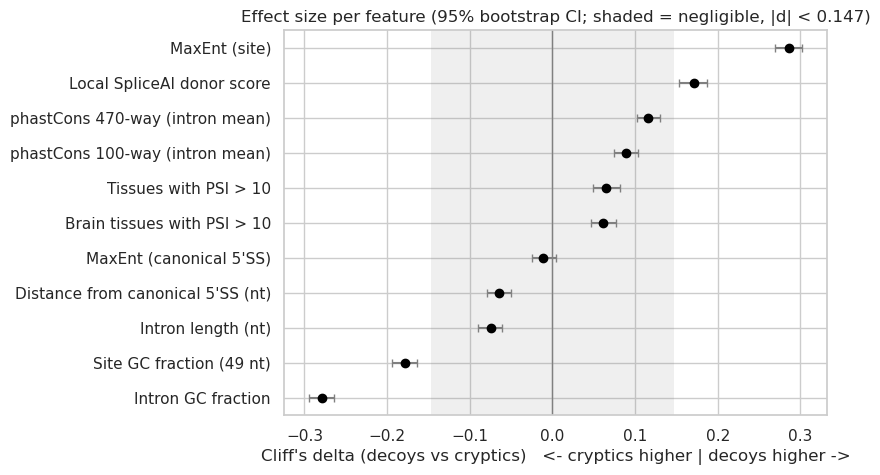

In [5]:
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    # U statistic route: delta = 2*AUC - 1
    u = stats.mannwhitneyu(a, b, alternative="two-sided").statistic
    return 2 * u / (len(a) * len(b)) - 1

def delta_ci(a, b, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(a); b = np.asarray(b)
    out = np.empty(n_boot)
    for i in range(n_boot):
        out[i] = cliffs_delta(rng.choice(a, len(a)), rng.choice(b, len(b)))
    return np.percentile(out, [2.5, 97.5])

rows = []
dec = df[df.site_class == "decoy"]; cry = df[df.site_class == "cryptic_supported"]
for f in FEATURES:
    a, b = dec[f].dropna(), cry[f].dropna()
    p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    d = cliffs_delta(a, b); lo, hi = delta_ci(a, b)
    rows.append({"feature": f, "decoy_median": a.median(), "cryptic_median": b.median(),
                 "cliffs_delta": d, "ci_low": lo, "ci_high": hi, "mwu_p": p})
eff = pd.DataFrame(rows)
eff["p_bh"] = stats.false_discovery_control(eff["mwu_p"], method="bh")
eff = eff.sort_values("cliffs_delta")
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
display(eff.reset_index(drop=True))
eff.to_csv(FIG / "D_effect_sizes.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(eff))
ax.errorbar(eff["cliffs_delta"], y, xerr=[eff["cliffs_delta"] - eff["ci_low"], eff["ci_high"] - eff["cliffs_delta"]],
            fmt="o", color="black", ecolor="grey", capsize=3)
ax.axvline(0, color="grey", lw=1)
ax.axvspan(-0.147, 0.147, color="grey", alpha=0.12, lw=0)
ax.set_yticks(y); ax.set_yticklabels([LABEL[f] for f in eff["feature"]])
ax.set_xlabel("Cliff's delta (decoys vs cryptics)   <- cryptics higher | decoys higher ->")
ax.set_title("Effect size per feature (95% bootstrap CI; shaded = negligible, |d| < 0.147)")
save(fig, "D1_effect_sizes")
plt.show()

pseudo R2 = 0.087   n = 24,218


,coef,ci_low,ci_high,p,odds_ratio_per_SD,VIF
intron_gc,-0.5565,-0.5979,-0.515,1.372e-152,0.5732,1.777
log10_intron_length,-0.1975,-0.2462,-0.1488,1.932e-15,0.8208,2.57
decoy_distance_from_canonical_5ss,-0.02413,-0.0684,0.02014,0.2854,0.9762,2.215
phastCons100_mean,-0.01631,-0.07933,0.04672,0.6121,0.9838,4.728
MaxEnt_canonical,0.007213,-0.0229,0.03732,0.6387,1.007,1.002
site_gc_49nt,0.02507,-0.01296,0.0631,0.1963,1.025,1.631
phastCons470_mean,0.07412,0.01077,0.1375,0.02183,1.077,4.664
psi_count_ge10,0.1866,0.1576,0.2157,2.232e-36,1.205,1.018
SpliceAI_score,0.2568,0.2277,0.286,8.436e-67,1.293,1.017
MaxEnt_decoy,0.6921,0.6006,0.7835,8.974e-50,1.998,1.239


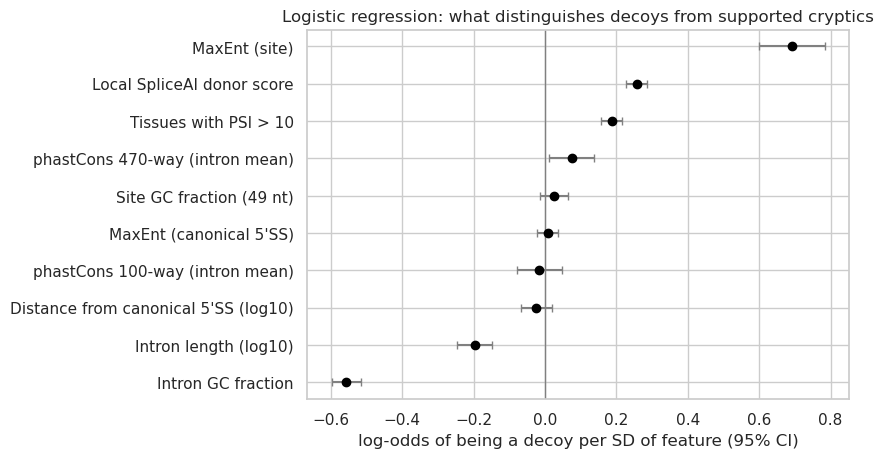

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_FEATS = ["log10_intron_length", "intron_gc", "site_gc_49nt", "SpliceAI_score",
           "decoy_distance_from_canonical_5ss", "MaxEnt_decoy", "MaxEnt_canonical",
           "phastCons100_mean", "phastCons470_mean", "psi_count_ge10"]
Z = df[X_FEATS].copy()
Z["decoy_distance_from_canonical_5ss"] = np.log10(Z["decoy_distance_from_canonical_5ss"])
Z = (Z - Z.mean()) / Z.std()
Z = sm.add_constant(Z)
yy = (df["site_class"] == "decoy").astype(int)
logit = sm.Logit(yy, Z).fit(disp=0)
coef = pd.DataFrame({"coef": logit.params, "ci_low": logit.conf_int()[0], "ci_high": logit.conf_int()[1], "p": logit.pvalues}).drop("const")
coef["odds_ratio_per_SD"] = np.exp(coef["coef"])
coef["VIF"] = [variance_inflation_factor(Z.values, i) for i, c in enumerate(Z.columns) if c != "const"]
coef = coef.sort_values("coef")
print(f"pseudo R2 = {logit.prsquared:.3f}   n = {len(yy):,}")
display(coef)

fig, ax = plt.subplots(figsize=(7, 4.8))
y = np.arange(len(coef))
ax.errorbar(coef["coef"], y, xerr=[coef["coef"] - coef["ci_low"], coef["ci_high"] - coef["coef"]], fmt="o", color="black", ecolor="grey", capsize=3)
ax.axvline(0, color="grey", lw=1)
ax.set_yticks(y); ax.set_yticklabels([LABEL.get(f, f).replace("(nt)", "(log10)") if f != "log10_intron_length" else "Intron length (log10)" for f in coef.index])
ax.set_xlabel("log-odds of being a decoy per SD of feature (95% CI)")
ax.set_title("Logistic regression: what distinguishes decoys from supported cryptics")
save(fig, "D2_logistic_class")
plt.show()

In [7]:
nb_form = ("psi_count_ge10 ~ C(site_class, Treatment('cryptic_supported')) + intron_gc + log10_intron_length"
           " + MaxEnt_decoy + MaxEnt_canonical + phastCons100_mean + SpliceAI_score")
nb_adj = smf.glm(nb_form, data=df, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
nb_raw = smf.glm("psi_count_ge10 ~ C(site_class, Treatment('cryptic_supported'))", data=df,
                 family=sm.families.NegativeBinomial(alpha=1.0)).fit()
cls_term = [c for c in nb_adj.params.index if "site_class" in c][0]
print("Tissue count, decoys relative to cryptics (rate ratio = exp(coef)):")
print(f"  unadjusted: {np.exp(nb_raw.params[cls_term]):.3f}   p = {nb_raw.pvalues[cls_term]:.2g}")
print(f"  adjusted:   {np.exp(nb_adj.params[cls_term]):.3f}   p = {nb_adj.pvalues[cls_term]:.2g}")
print()
tab = pd.DataFrame({"rate_ratio": np.exp(nb_adj.params), "ci_low": np.exp(nb_adj.conf_int()[0]),
                    "ci_high": np.exp(nb_adj.conf_int()[1]), "p": nb_adj.pvalues}).drop("Intercept")
display(tab)

Tissue count, decoys relative to cryptics (rate ratio = exp(coef)):
  unadjusted: 1.145   p = 5.2e-20
  adjusted:   1.196   p = 4e-31



,rate_ratio,ci_low,ci_high,p
"C(site_class, Treatment('cryptic_supported'))[T.decoy]",1.196,1.16,1.232,3.984e-31
intron_gc,4.012,3.381,4.761,5.16e-57
log10_intron_length,1.123,1.086,1.162,1.243e-11
MaxEnt_decoy,0.9992,0.9969,1.001,0.493
MaxEnt_canonical,0.9981,0.9974,0.9989,1.3e-06
phastCons100_mean,3.867,3.07,4.871,1.601e-30
SpliceAI_score,1.141,1.006,1.293,0.04015


## E. Further exploration

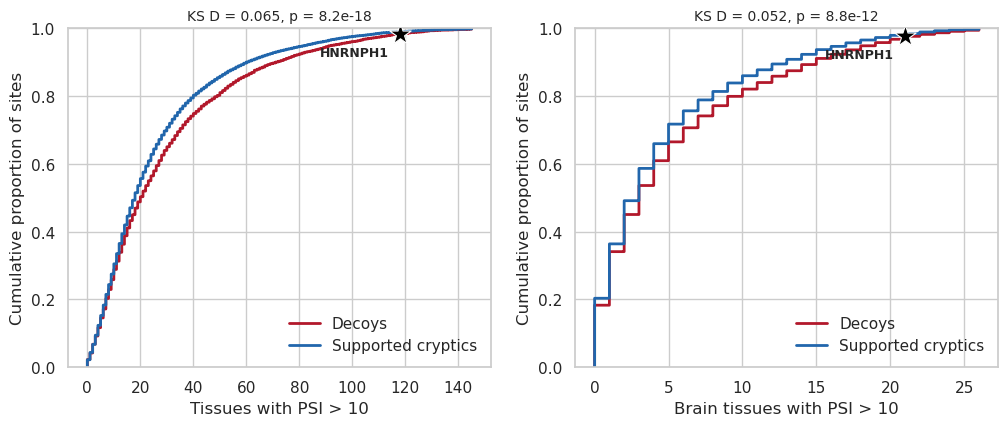

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, col in zip(axes, ["psi_count_ge10", "psi_count_ge10_brain"]):
    for cls in CLASSES:
        sns.ecdfplot(df.loc[df.site_class == cls, col], ax=ax, color=COLOR[cls], lw=2, label=CLASS_LABEL[cls])
    ks = stats.ks_2samp(dec[col], cry[col])
    x_hn = HN[col]
    mark_hnrnph1(ax, x_hn, (dec[col] <= x_hn).mean(), dy=-16)
    ax.set_xlabel(LABEL[col]); ax.set_ylabel("Cumulative proportion of sites")
    ax.set_title(f"KS D = {ks.statistic:.3f}, p = {ks.pvalue:.2g}", fontsize=10)
    ax.legend(frameon=False)
save(fig, "E1_ecdf_tissue_counts")
plt.show()

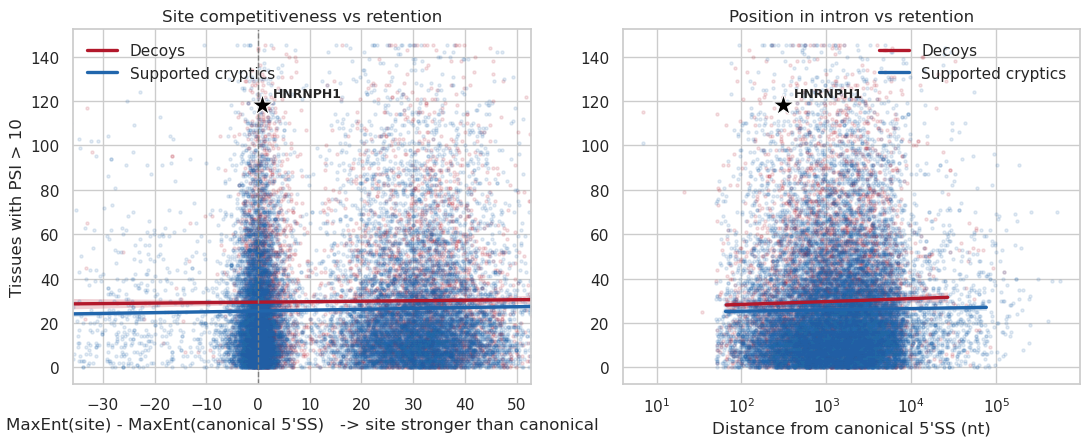

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for cls in CLASSES:
    sub = df[df.site_class == cls]
    axes[0].scatter(sub["maxent_delta"], sub["psi_count_ge10"], s=5, alpha=0.12, color=COLOR[cls], rasterized=True)
    grid = np.linspace(*df["maxent_delta"].quantile([0.005, 0.995]), 200)
    m, pr = nb_line(sub, "maxent_delta", grid)
    axes[0].plot(grid, pr["mean"], color=COLOR[cls], lw=2.4, label=CLASS_LABEL[cls])
    axes[0].fill_between(grid, pr["mean_ci_lower"], pr["mean_ci_upper"], color=COLOR[cls], alpha=0.2, lw=0)
axes[0].axvline(0, color="grey", lw=1, ls="--")
axes[0].set_xlim(*df["maxent_delta"].quantile([0.005, 0.995]))
mark_hnrnph1(axes[0], HN["maxent_delta"], HN["psi_count_ge10"])
axes[0].set_xlabel("MaxEnt(site) - MaxEnt(canonical 5'SS)   -> site stronger than canonical")
axes[0].set_ylabel("Tissues with PSI > 10"); axes[0].set_title("Site competitiveness vs retention"); axes[0].legend(frameon=False)

for cls in CLASSES:
    sub = df[df.site_class == cls]
    axes[1].scatter(sub["decoy_distance_from_canonical_5ss"], sub["psi_count_ge10"], s=5, alpha=0.12, color=COLOR[cls], rasterized=True)
    sub = sub.assign(log_dist=np.log10(sub["decoy_distance_from_canonical_5ss"]))
    grid = np.linspace(*sub["log_dist"].quantile([0.005, 0.995]), 200)
    m, pr = nb_line(sub, "log_dist", grid)
    axes[1].plot(10 ** grid, pr["mean"], color=COLOR[cls], lw=2.4, label=CLASS_LABEL[cls])
    axes[1].fill_between(10 ** grid, pr["mean_ci_lower"], pr["mean_ci_upper"], color=COLOR[cls], alpha=0.2, lw=0)
axes[1].set_xscale("log"); axes[1].set_xlabel(LABEL["decoy_distance_from_canonical_5ss"])
mark_hnrnph1(axes[1], HN["decoy_distance_from_canonical_5ss"], HN["psi_count_ge10"])
axes[1].set_title("Position in intron vs retention"); axes[1].legend(frameon=False)
save(fig, "E2_competitiveness_and_position")
plt.show()

group
Supported cryptics   18
Decoy, 1 track(s)    19
Decoy, 2 track(s)    28
Decoy, 3 track(s)    32


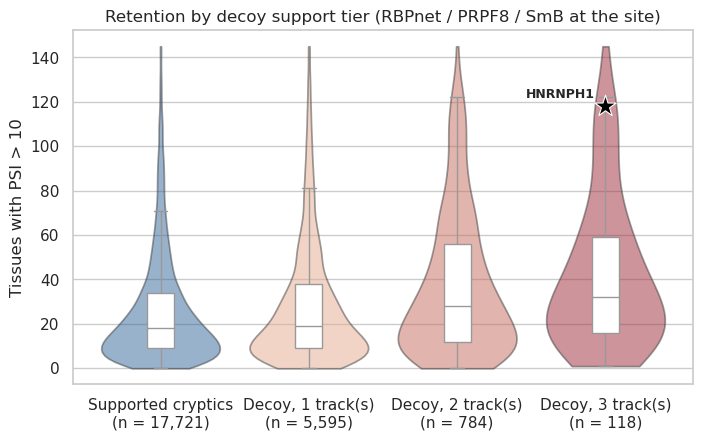

In [10]:
tier = df.copy()
tier["group"] = np.where(tier.site_class == "decoy", "Decoy, " + tier["n_categories"].astype(str) + " track(s)", "Supported cryptics")
order = ["Supported cryptics", "Decoy, 1 track(s)", "Decoy, 2 track(s)", "Decoy, 3 track(s)"]
pal = {"Supported cryptics": COLOR["cryptic_supported"], "Decoy, 1 track(s)": "#F4A582", "Decoy, 2 track(s)": "#D6604D", "Decoy, 3 track(s)": "#B2182B"}
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.violinplot(data=tier, x="group", y="psi_count_ge10", order=order, hue="group", hue_order=order, palette=pal, legend=False, cut=0, inner=None, alpha=0.5, ax=ax)
sns.boxplot(data=tier, x="group", y="psi_count_ge10", order=order, width=0.18, showfliers=False, color="white", ax=ax)
counts = tier["group"].value_counts()
ax.set_xticks(range(len(order)), [f"{g}\n(n = {counts[g]:,})" for g in order])
hn_group = order.index(f"Decoy, {int(HN['n_categories'])} track(s)")
mark_hnrnph1(ax, hn_group, HN["psi_count_ge10"])
ax.set_xlabel(""); ax.set_ylabel("Tissues with PSI > 10")
ax.set_title("Retention by decoy support tier (RBPnet / PRPF8 / SmB at the site)")
print(tier.groupby("group")["psi_count_ge10"].median().reindex(order).rename("median tissues").to_string())
save(fig, "E3_support_tier")
plt.show()

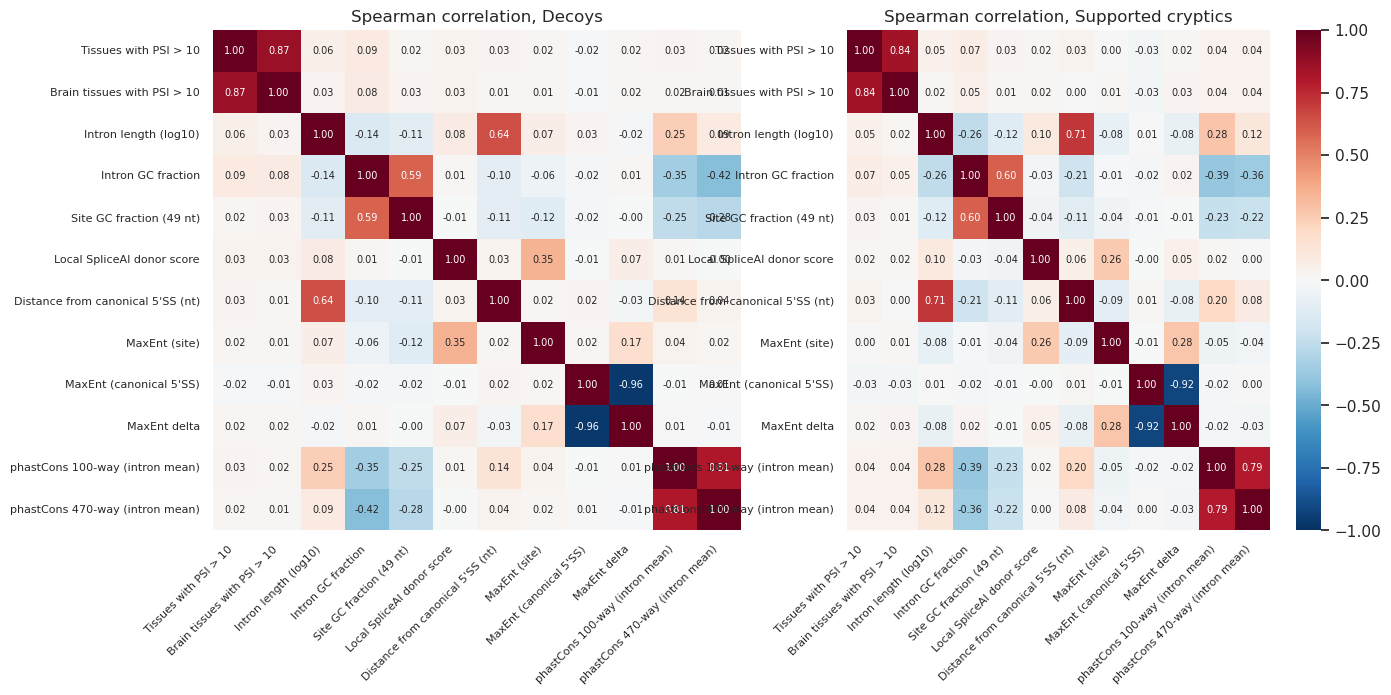

In [11]:
corr_feats = ["psi_count_ge10", "psi_count_ge10_brain", "log10_intron_length", "intron_gc", "site_gc_49nt",
              "SpliceAI_score", "decoy_distance_from_canonical_5ss", "MaxEnt_decoy", "MaxEnt_canonical",
              "maxent_delta", "phastCons100_mean", "phastCons470_mean"]
names = [LABEL.get(f, f) for f in corr_feats]
names = [n.replace("log10_intron_length", "Intron length (log10)").replace("maxent_delta", "MaxEnt delta") for n in names]
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, cls in zip(axes, CLASSES):
    c = df.loc[df.site_class == cls, corr_feats].corr(method="spearman")
    sns.heatmap(c, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
                xticklabels=names, yticklabels=names, cbar=(cls == "cryptic_supported"))
    ax.set_title(f"Spearman correlation, {CLASS_LABEL[cls]}")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8); plt.setp(ax.get_yticklabels(), fontsize=8)
save(fig, "E4_correlation_heatmaps")
plt.show()

## Notes

- Everything above is descriptive of one snapshot of the pipeline. Re-run the notebook after
  any change to `compile_decoy_intron_data.Rmd`; it reads only the final table.
- Effect sizes and adjusted models are the numbers to quote. With these sample sizes p-values
  alone will call almost any difference significant.
- The two classes differ by construction in CLIP support at the site, and the cryptic class was
  further required to have an annotated canonical donor in a Vast-DB intron. Differences in intron
  length or GC between classes may partly reflect those selection steps rather than biology.